#  End-to-End Sales Forecasting & Demand Intelligence System


# Task 1: Data Loading, Merging & Deep Exploration

## Objective
The objective of this task is to load the Superstore Sales dataset, inspect its structure, clean the data, engineer useful time-based features, and perform exploratory analysis to understand sales trends across categories, regions, and time. These insights will serve as the foundation for forecasting, anomaly detection, and demand segmentation in the subsequent tasks.

In [1]:
# Importing necessary libraries

import warnings
warnings.filterwarnings("ignore")


# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the Dataset

df = pd.read_csv(
    "train.csv",
    parse_dates=["Order Date", "Ship Date"],
    dayfirst=True
)

print("Dataset loaded successfully.\n")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Dataset loaded successfully.

Rows    : 9800
Columns : 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Basic Dataset Information

print("Dataset Information")
display(df.info())

print("\nStatistical Summary")
display(df.describe(include="all"))

print("\nData Types")
display(df.dtypes)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category

None


Statistical Summary


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,NaN,NaN,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,NaN,NaN,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,2017-05-01 05:13:51.673469,2017-05-05 04:17:52.653061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25%,2450.750000,NaN,2016-05-24 00:00:00,2016-05-27 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,2017-06-26 00:00:00,2017-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,2018-05-15 00:00:00,2018-05-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000
max,9800.000000,NaN,2018-12-30 00:00:00,2019-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99301.000000,NaN,NaN,NaN,NaN,NaN,22638.480000



Data Types


Row ID                   int64
Order ID                   str
Order Date      datetime64[us]
Ship Date       datetime64[us]
Ship Mode                  str
                     ...      
Product ID                 str
Category                   str
Sub-Category               str
Product Name               str
Sales                  float64
Length: 18, dtype: object

In [4]:
# Initial Data Exploration

#Before preprocessing the dataset, 
# it is important to understand its overall structure and quality. 
# This section examines the dataset dimensions, column names, data types, missing values, duplicate records, and unique values. 
# These checks help identify potential data quality issues that could affect subsequent analysis and model performance.

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")



Number of Rows    : 9800
Number of Columns : 18


In [5]:
# column names

print("Columns in the Dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the Dataset:

1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Customer Name
8. Segment
9. Country
10. City
11. State
12. Postal Code
13. Region
14. Product ID
15. Category
16. Sub-Category
17. Product Name
18. Sales


In [6]:
# Missing Values

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df) * 100).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_df.sort_values(by="Missing Values", ascending=False))

,Missing Values,Percentage
Postal Code,11,0.11


In [7]:
# Duplicate Records

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [8]:
# Unique Values in Each Column

unique_df = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

display(unique_df)

,Column,Unique Values
0,Row ID,9800
1,Order ID,4922
2,Order Date,1230
3,Ship Date,1326
4,Ship Mode,4
...,...,...
13,Product ID,1861
14,Category,3
15,Sub-Category,17
16,Product Name,1849


In [9]:
# Display Random Sample Records


df.sample(5, random_state=42)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
532,533,US-2018-129441,2018-09-07,2018-09-11,Standard Class,JC-15340,Jasper Cacioppo,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10000448,Furniture,Furnishings,Tenex Chairmats For Use With Carpeted Floors,47.94
872,873,CA-2015-148488,2015-12-10,2015-12-15,Standard Class,SM-20005,Sally Matthias,Consumer,United States,New York City,New York,10009.0,East,OFF-PA-10004470,Office Supplies,Paper,"Adams Write n' Stick Phone Message Book, 11"" X...",11.36
1149,1150,CA-2016-112452,2016-04-04,2016-04-04,Same Day,NC-18340,Nat Carroll,Consumer,United States,Lansing,Michigan,48911.0,Central,TEC-PH-10000307,Technology,Phones,Shocksock Galaxy S4 Armband,10.95
2287,2288,US-2018-112928,2018-06-01,2018-06-05,Second Class,BB-10990,Barry Blumstein,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AP-10002287,Office Supplies,Appliances,Eureka Sanitaire Multi-Pro Heavy-Duty Upright...,17.48
4038,4039,CA-2015-110786,2015-12-29,2016-01-02,Standard Class,AJ-10795,Anthony Johnson,Corporate,United States,San Francisco,California,94110.0,West,OFF-PA-10000528,Office Supplies,Paper,Xerox 1981,21.12


In [10]:
# Data Cleaning

#Data cleaning is an essential step before any analysis or machine learning. 
# In this section, the dataset is checked for incorrect values, duplicate records, inconsistent text formatting, 
# and additional business features are created. 
# A new feature, Shipping Time (Days), is calculated to measure the delivery duration between the order date and ship date.

print(df.dtypes)


Row ID                   int64
Order ID                   str
Order Date      datetime64[us]
Ship Date       datetime64[us]
Ship Mode                  str
                     ...      
Product ID                 str
Category                   str
Sub-Category               str
Product Name               str
Sales                  float64
Length: 18, dtype: object


In [11]:
# Create Shipping Time Feature

df["Shipping Time (Days)"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("Shipping Time feature created successfully.")

df[["Order Date", "Ship Date", "Shipping Time (Days)"]].head()

Shipping Time feature created successfully.


,Order Date,Ship Date,Shipping Time (Days)
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [12]:
# Check Negative or Zero Sales

invalid_sales = df[df["Sales"] <= 0]

print(f"Number of records with Sales <= 0 : {len(invalid_sales)}")

invalid_sales.head()

Number of records with Sales <= 0 : 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Shipping Time (Days)


In [13]:
# Standardize Text Columns

text_columns = [
    "Category",
    "Sub-Category",
    "Region",
    "State",
    "City",
    "Segment",
    "Ship Mode"
]

for col in text_columns:
    df[col] = df[col].str.strip()

print("Text columns standardized successfully.")

Text columns standardized successfully.


In [14]:
# Verify Cleaned Dataset

print("Dataset Shape :", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

df.head()


# there are missing values so first lets handle this

Dataset Shape : (9800, 19)

Missing Values:
11

Duplicate Records:
0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Shipping Time (Days)
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7


In [15]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

display(missing_df)

,Missing Values,Percentage
Postal Code,11,0.11


In [16]:
# handling missing values

# Postal Code has only 11 missing values (0.11%).
# Since Postal Code is not required for forecasting or analysis,
# we keep these records to avoid unnecessary data loss.

print("Missing Values Before Handling:")
print(df.isnull().sum())

# No rows are removed because the missing values are only in Postal Code.

print("\nNo missing values were imputed or removed.")
print("Reason: Postal Code is not a critical feature for this project.")

Missing Values Before Handling:
Row ID                  0
Order ID                0
Order Date              0
Ship Date               0
Ship Mode               0
                       ..
Category                0
Sub-Category            0
Product Name            0
Sales                   0
Shipping Time (Days)    0
Length: 19, dtype: int64

No missing values were imputed or removed.
Reason: Postal Code is not a critical feature for this project.


In [17]:
#Feature Engineering

#Feature engineering transforms raw data into meaningful variables that improve analysis and forecasting. 
# Since this project focuses on time-series forecasting, 
# extracting time-based features from the order date is essential for understanding sales patterns, seasonality, and long-term trends.

#The following features are created:
# - Year
# - Month
# - Month Name
# - Week Number
# - Day of Week
# - Quarter
# - Season



In [18]:
# Create Time Features

# Year
df["Year"] = df["Order Date"].dt.year

# Month Number
df["Month"] = df["Order Date"].dt.month

# Month Name
df["Month Name"] = df["Order Date"].dt.month_name()

# Week Number (ISO Week)
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)

# Day Name
df["Day of Week"] = df["Order Date"].dt.day_name()

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

print("Time-based features created successfully.")

Time-based features created successfully.


In [19]:
# Create Season Feature

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

print("Season feature created successfully.")

Season feature created successfully.


In [20]:
# once checking if features are created successfully

df[
    [
        "Order Date",
        "Year",
        "Month",
        "Month Name",
        "Week Number",
        "Day of Week",
        "Quarter",
        "Season",
        "Shipping Time (Days)"
    ]
].head(10)

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season,Shipping Time (Days)
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn,3
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn,3
2,2017-06-12,2017,6,June,24,Monday,2,Summer,4
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn,7
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn,7
5,2015-06-09,2015,6,June,24,Tuesday,2,Summer,5
6,2015-06-09,2015,6,June,24,Tuesday,2,Summer,5
7,2015-06-09,2015,6,June,24,Tuesday,2,Summer,5
8,2015-06-09,2015,6,June,24,Tuesday,2,Summer,5
9,2015-06-09,2015,6,June,24,Tuesday,2,Summer,5


In [21]:
# Check Feature Distributions

print("Years:")
print(sorted(df["Year"].unique()))

print("\nMonths:")
print(sorted(df["Month"].unique()))

print("\nQuarters:")
print(sorted(df["Quarter"].unique()))

print("\nSeasons:")
print(df["Season"].unique())

print("\nDays of Week:")
print(df["Day of Week"].unique())

Years:
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]

Months:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

Quarters:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4)]

Seasons:
<StringArray>
['Autumn', 'Summer', 'Spring', 'Winter']
Length: 4, dtype: str

Days of Week:
<StringArray>
['Wednesday', 'Monday', 'Tuesday', 'Sunday', 'Thursday', 'Saturday', 'Friday']
Length: 7, dtype: str


In [22]:
# Sales Aggregation

#Time series forecasting requires sales data to be organized at different time granularities. 
# In this section, the transaction-level dataset is aggregated into daily, weekly, and monthly sales. 
# These aggregated datasets will be used for trend analysis, forecasting models, and anomaly detection in the later stages of the project.

In [23]:
# Daily Sales Aggregation

daily_sales = (
    df.groupby("Order Date", as_index=False)["Sales"]
      .sum()
      .sort_values("Order Date")
)

print("Daily Sales Shape :", daily_sales.shape)

daily_sales.head()

Daily Sales Shape : (1230, 2)


,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [24]:
# Weekly Sales Aggregation

weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .reset_index()
)

print("Weekly Sales Shape :", weekly_sales.shape)

weekly_sales.head()

Weekly Sales Shape : (209, 2)


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [25]:
# Monthly Sales Aggregation

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

print("Monthly Sales Shape :", monthly_sales.shape)

monthly_sales.head()

Monthly Sales Shape : (48, 2)


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [26]:
# Summary of Aggregated Datasets

print(f"Daily Records   : {len(daily_sales)}")

print(f"Weekly Records  : {len(weekly_sales)}")

print(f"Monthly Records : {len(monthly_sales)}")

Daily Records   : 1230
Weekly Records  : 209
Monthly Records : 48


In [27]:
# Optional: Saving the  aggregated datasets


import os

OUTPUT_DIR = "Aggregated Datasets"

# Create the folder only if it doesn't already exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

daily_sales.to_csv(
    os.path.join(OUTPUT_DIR, "daily_sales.csv"),
    index=False
)

weekly_sales.to_csv(
    os.path.join(OUTPUT_DIR, "weekly_sales.csv"),
    index=False
)

monthly_sales.to_csv(
    os.path.join(OUTPUT_DIR, "monthly_sales.csv"),
    index=False
)

print(f"Files saved successfully in '{OUTPUT_DIR}' folder.")




Files saved successfully in 'Aggregated Datasets' folder.


## Business Question 1

### Which product category generates the highest total revenue?

Understanding which product category contributes the highest revenue helps businesses prioritize inventory planning, marketing strategies, and resource allocation. This analysis calculates the total sales generated by each product category and visualizes the results for comparison.

In [28]:
# Total Revenue by Product Category

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales.rename(columns={"Sales": "Total Revenue"}, inplace=True)

category_sales

,Category,Total Revenue
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


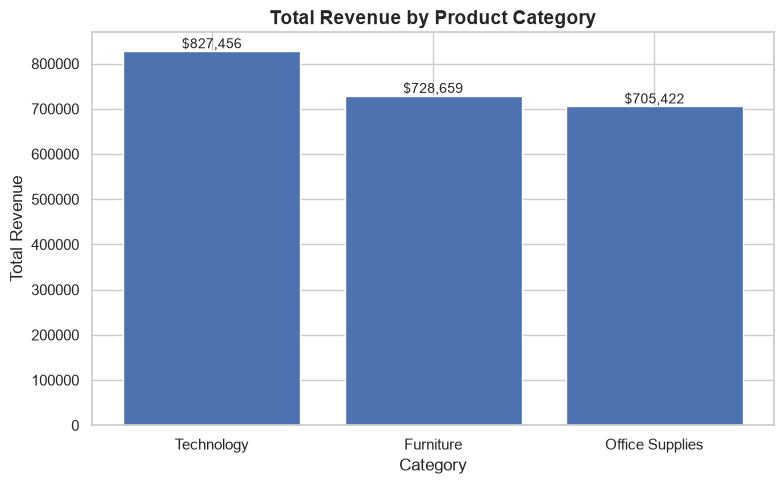

In [29]:
# Visualization


plt.figure(figsize=(8,5))

bars = plt.bar(
    category_sales["Category"],
    category_sales["Total Revenue"]
)

plt.title("Total Revenue by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.show()

In [30]:
import os

OUTPUT_DIR = "Charts for task1 business insights"

# Create the folder only if it doesn't already exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save Figure

plt.figure(figsize=(8,5))

bars = plt.bar(
    category_sales["Category"],
    category_sales["Total Revenue"]
)

plt.title("Total Revenue by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/category_revenue.png", dpi=300)

plt.close()
# plt.show()

### Business Interpretation

The analysis shows that the **Technology** category generates the highest total revenue among all product categories, followed by **Furniture** and **Office Supplies**.

This indicates that technology products contribute the largest share of sales revenue and should be prioritized for inventory management, demand forecasting, and promotional campaigns. Maintaining sufficient stock levels for high-revenue technology products can help maximize sales while minimizing the risk of stock shortages.

## Business Question 2

### Which region has the most consistent sales growth over the four-year period?

Understanding regional sales performance helps businesses identify markets with stable demand and long-term growth potential. This analysis examines annual sales trends across different regions to determine which region demonstrates the most consistent growth over time.

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
...,...,...,...
11,2017,West,182471.2285
12,2018,Central,141627.3402
13,2018,East,210129.1860
14,2018,South,122164.5675


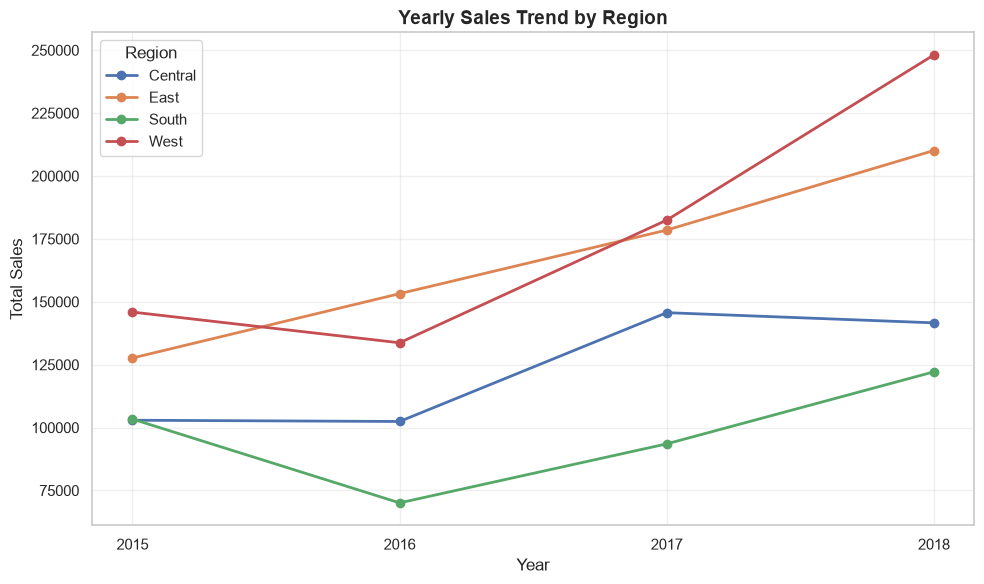

In [31]:


# Aggregate yearly sales by region
region_yearly_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

# Display the yearly sales table
display(region_yearly_sales)

# Plot yearly sales trend for each region
plt.figure(figsize=(10,6))

for region in region_yearly_sales["Region"].unique():
    region_data = region_yearly_sales[
        region_yearly_sales["Region"] == region
    ]

    plt.plot(
        region_data["Year"],
        region_data["Sales"],
        marker="o",
        linewidth=2,
        label=region
    )

plt.title("Yearly Sales Trend by Region", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(sorted(df["Year"].unique()))
plt.legend(title="Region")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig(f"{OUTPUT_DIR}/region_sales_growth.png", dpi=300)

plt.show()

### Business Interpretation

The **West** region demonstrates the most consistent and strongest sales growth over the four-year period. Despite a slight decline in 2016, sales increased significantly during 2017 and 2018, ultimately recording the highest annual revenue among all regions.

The **East** region also exhibits a stable upward trend, while the **Central** and **South** regions show greater fluctuations in sales performance.

From a business perspective, the West region represents a high-growth market and should be prioritized for inventory planning, demand forecasting, and future business expansion. Maintaining adequate stock levels and investing in marketing initiatives within this region can help maximize future revenue opportunities.

## Business Question 3

### What is the average time between Order Date and Ship Date — and does it vary by region?

Shipping time is an important operational metric that reflects the efficiency of the order fulfillment process. This analysis calculates the average delivery time between the order date and ship date for each region to identify regional differences in shipping performance.

,Region,Shipping Time (Days)
0,East,3.91
1,West,3.93
2,South,3.96
3,Central,4.07


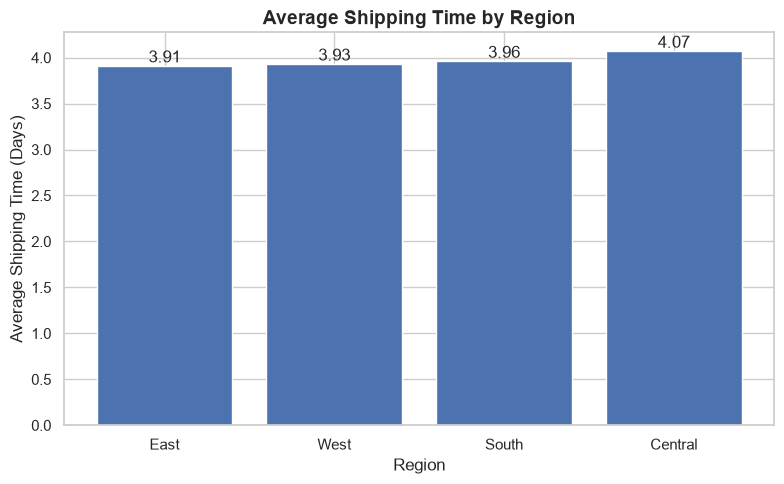

In [32]:


# Calculate average shipping time for each region
shipping_time = (
    df.groupby("Region")["Shipping Time (Days)"]
      .mean()
      .round(2)
      .sort_values()
      .reset_index()
)

display(shipping_time)

# Plot
plt.figure(figsize=(8,5))

bars = plt.bar(
    shipping_time["Region"],
    shipping_time["Shipping Time (Days)"]
)

plt.title("Average Shipping Time by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Average Shipping Time (Days)")

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# Save chart
plt.savefig(f"{OUTPUT_DIR}/shipping_time_by_region.png", dpi=300)

plt.show()

### Business Interpretation

The average shipping time across all regions ranges from **3.91 to 4.07 days**, indicating a highly consistent order fulfillment process throughout the business.

The **East** region has the fastest average shipping time (**3.91 days**), while the **Central** region has the longest (**4.07 days**). However, the differences between regions are minimal, suggesting that the company's logistics and distribution network performs consistently .

From an operational perspective, the shipping process appears to be well standardized, with only minor opportunities for improvement in the Central region to further reduce delivery times.

## Business Question 4

### Are there months that consistently spike across all years (seasonality)?

Identifying recurring monthly sales patterns helps businesses understand seasonality and anticipate periods of high or low demand. This analysis examines monthly sales trends across all four years to determine whether certain months consistently generate higher revenue.

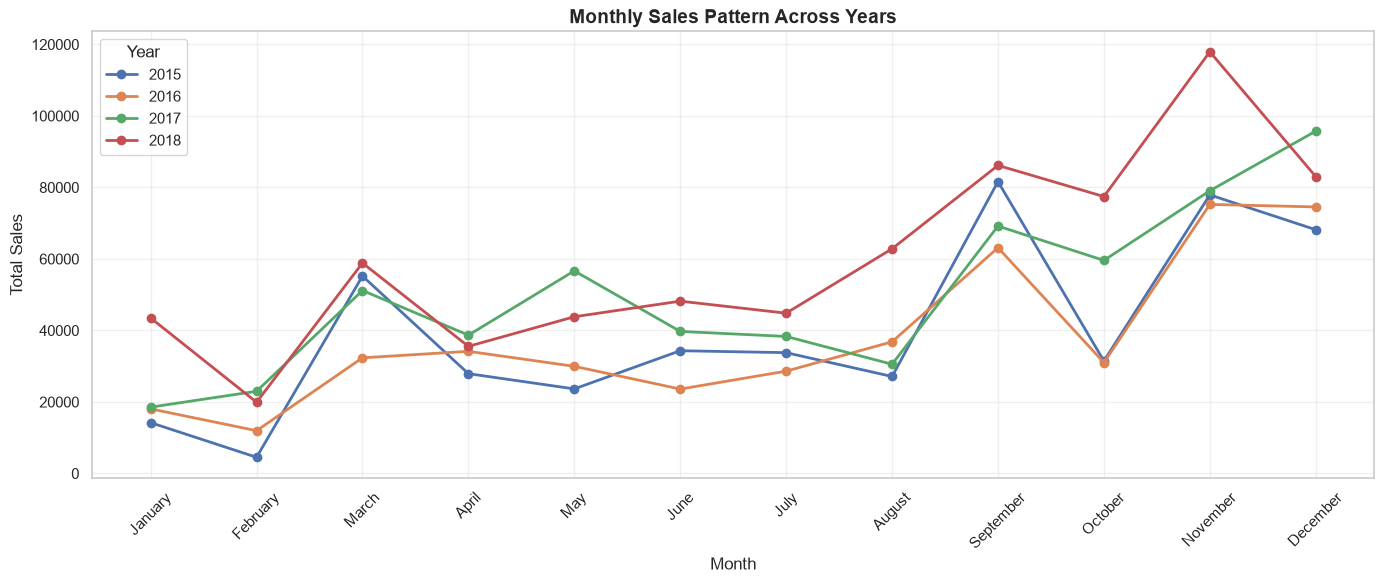

,Year,Month Name,Month,Sales
4,2015,January,1,14205.7070
3,2015,February,2,4519.8920
7,2015,March,3,55205.7970
0,2015,April,4,27906.8550
8,2015,May,5,23644.3030
...,...,...,...,...
37,2018,August,8,62837.8480
47,2018,September,9,86152.8880
46,2018,October,10,77448.1312
45,2018,November,11,117938.1550


In [33]:


# Monthly sales by Year and Month
monthly_pattern = (
    df.groupby(["Year", "Month Name", "Month"])["Sales"]
      .sum()
      .reset_index()
      .sort_values(["Year", "Month"])
)

# Plot monthly sales trend for each year
plt.figure(figsize=(14,6))

for year in sorted(monthly_pattern["Year"].unique()):
    year_data = monthly_pattern[monthly_pattern["Year"] == year]

    plt.plot(
        year_data["Month Name"],
        year_data["Sales"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title("Monthly Sales Pattern Across Years", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig(f"{OUTPUT_DIR}/monthly_seasonality.png", dpi=300)

plt.show()

# Display monthly sales table
display(monthly_pattern)

### Business Interpretation

The monthly sales analysis reveals a clear seasonal pattern across all four years. Sales generally remain moderate during the first half of the year and increase significantly during the final quarter (Q4), particularly in **September, November, and December**.

Among all months, **November** consistently records the highest sales, while **December** also shows strong performance across most years. This trend is likely influenced by major shopping events such as Black Friday, Cyber Monday, holiday promotions, and year-end purchasing.

From a business perspective, the company should increase inventory levels, optimize supply chain operations, and plan promotional campaigns ahead of the fourth quarter to meet the expected rise in customer demand and avoid stock shortages.

## Task 1 Summary

In this task, the Superstore Sales dataset was successfully loaded, cleaned, and prepared for analysis. Time-based features such as year, month, week number, quarter, season, and shipping time were engineered to support time series forecasting and business analysis.

The exploratory analysis revealed that:
- **Technology** generated the highest total revenue.
- The **West** region demonstrated the strongest long-term sales growth.
- Shipping times remained consistent across all regions, averaging approximately four days.
- A clear seasonal pattern was observed, with sales consistently peaking during the fourth quarter, especially in **November** and **December**.

The cleaned dataset and aggregated daily, weekly, and monthly sales data are now ready for advanced time series decomposition and forecasting in the next task.

# Task 2: Time Series Analysis & Decomposition

## Objective

The objective of this task is to analyze the overall sales trend over time and understand its underlying components. Time series decomposition separates the sales data into trend, seasonal, and residual components, making it easier to identify long-term growth patterns, recurring seasonal effects, and irregular fluctuations.

Additionally, the stationarity of the time series is evaluated using the Augmented Dickey-Fuller (ADF) test. If the series is found to be non-stationary, differencing is applied before performing the test again.

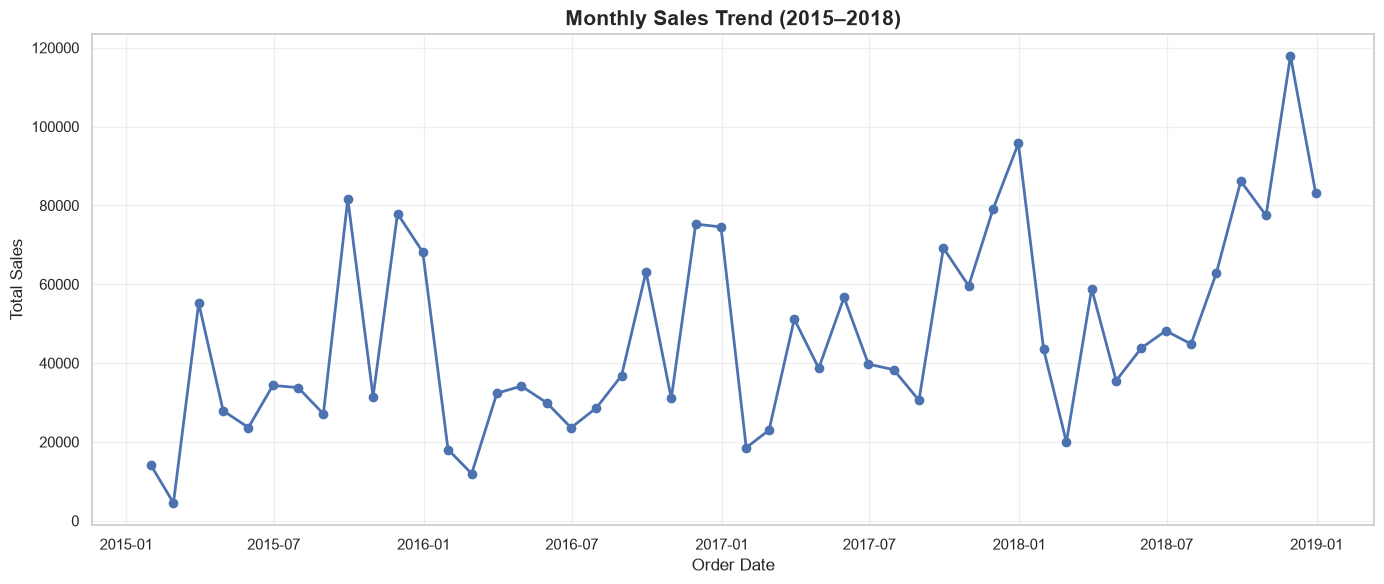

In [34]:
# Monthly Sales Trend

#The monthly sales trend provides a high-level view of how sales have changed throughout the four-year period. 
# Visualizing this trend helps identify long-term growth patterns, seasonal fluctuations, and any unusual changes in sales performance.

import os

OUTPUT_DIR = "Charts"

# Create the folder only if it doesn't already exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2,
    marker="o"
)

plt.title("Monthly Sales Trend (2015–2018)", fontsize=15, fontweight="bold")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig("charts/monthly_sales_trend.png", dpi=300)

plt.show()

### Observation

The monthly sales trend indicates an overall upward growth in sales over the four-year period. While sales fluctuate from month to month, a recurring increase is observed during the final quarter of each year, confirming the presence of seasonality. The highest sales values occur toward the end of the dataset, indicating continued business growth.

## Time Series Decomposition

Time series decomposition separates the sales data into its underlying components:
- **Observed:** The original monthly sales data.
- **Trend:** The long-term movement in sales over time.
- **Seasonal:** Recurring patterns that repeat over fixed intervals.
- **Residual:** Random fluctuations that cannot be explained by the trend or seasonal components.

This decomposition helps identify whether sales are influenced by long-term growth, seasonal demand, or irregular events.

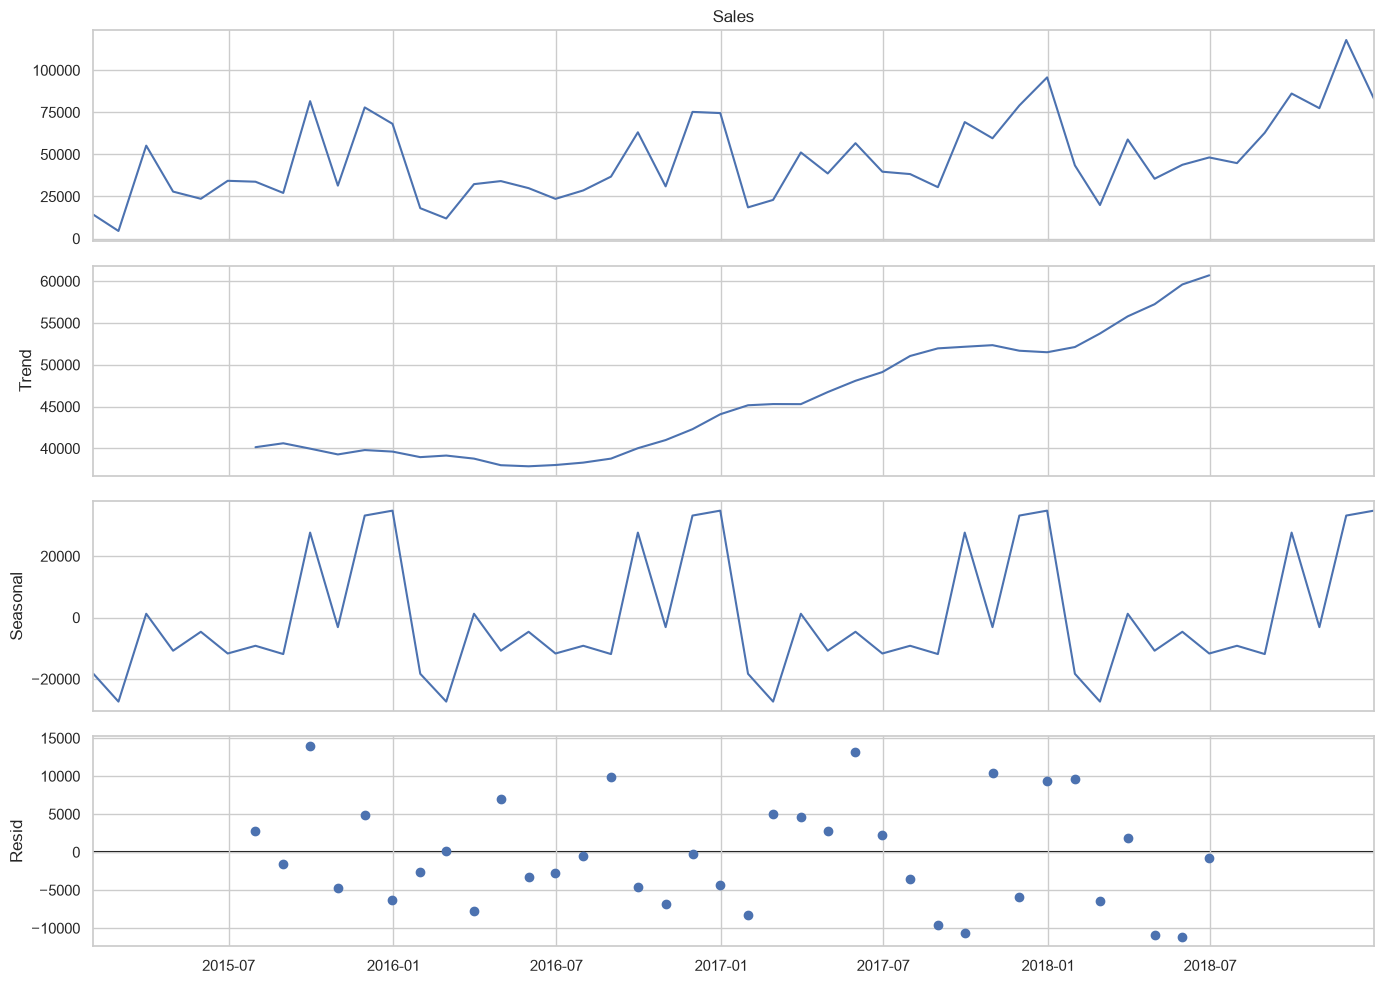

In [35]:


from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare monthly sales time series
ts = monthly_sales.copy()
ts.set_index("Order Date", inplace=True)

# Perform additive decomposition
decomposition = seasonal_decompose(
    ts["Sales"],
    model="additive",
    period=12
)

# Plot decomposition
fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()

# Save chart
plt.savefig("charts/time_series_decomposition.png", dpi=300)

plt.show()

### Observation

The time series decomposition reveals several important characteristics of the monthly sales data:

- **Trend:** The trend component shows a steady upward movement over the four-year period, indicating continuous business growth. Sales increase more rapidly from 2017 onwards, suggesting improved business performance during the later years.

- **Seasonality:** A strong seasonal pattern is present, with recurring peaks during the final quarter of each year. This confirms that customer demand follows a predictable annual cycle rather than occurring randomly.

- **Residual Noise:** The residual component is centered around zero, indicating that most of the variation is explained by the trend and seasonal components. The largest positive and negative residuals occur primarily during **late 2017 and early 2018**, suggesting a few exceptional months where sales were unusually higher or lower than expected.

Overall, the decomposition demonstrates that the monthly sales data contains a clear trend, strong seasonality, and relatively limited unexplained variation, making it well suited for forecasting models.

## Stationarity Test using the Augmented Dickey-Fuller (ADF) Test

Most time series forecasting models assume that the data is **stationary**, meaning that its statistical properties such as mean and variance remain relatively constant over time.

The Augmented Dickey-Fuller (ADF) test is used to determine whether the monthly sales series is stationary.

- **Null Hypothesis (H₀):** The time series is non-stationary.
- **Alternative Hypothesis (H₁):** The time series is stationary.

If the **p-value < 0.05**, we reject the null hypothesis and conclude that the series is stationary.

In [36]:
# adf test


from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
result = adfuller(monthly_sales["Sales"])

print("="*60)
print("Augmented Dickey-Fuller Test")
print("="*60)

print(f"ADF Statistic : {result[0]:.4f}")
print(f"P-value       : {result[1]:.4f}")
print(f"Lags Used     : {result[2]}")
print(f"Observations  : {result[3]}")

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

print("\nConclusion:")

if result[1] < 0.05:
    print("The time series is Stationary.")
else:
    print("The time series is Non-Stationary.")

Augmented Dickey-Fuller Test
ADF Statistic : -4.4161
P-value       : 0.0003
Lags Used     : 0
Observations  : 47

Critical Values:
1%: -3.5778
5%: -2.9253
10%: -2.6008

Conclusion:
The time series is Stationary.


### Observation

The Augmented Dickey-Fuller (ADF) test produced a **p-value of 0.0003**, which is significantly lower than the significance level of **0.05**. Therefore, the null hypothesis of non-stationarity is rejected.

This indicates that the monthly sales time series is **already stationary**, meaning its statistical properties remain sufficiently stable over time for forecasting purposes. As a result, **first-order differencing is not required**, and the original monthly sales series can be used directly for subsequent forecasting models.

 **In simple terms** , 
 a stationary time series is one whose average value, variability, and overall behavior remain relatively stable over time. Many forecasting models perform better when the data is stationary because they assume that future patterns will behave similarly to past patterns.

## Task 2 Summary

In this task, the monthly sales data was analyzed using time series techniques to understand its underlying structure. The sales trend demonstrated a gradual increase over the four-year period, while seasonal decomposition revealed a recurring annual sales pattern with noticeable peaks during the final quarter of each year.

The Augmented Dickey-Fuller (ADF) test confirmed that the monthly sales series is already stationary (**p-value = 0.0003**), indicating that no additional differencing is required before forecasting. These findings establish a strong foundation for building reliable forecasting models in the next task.

# Task 3: Sales Forecasting using 3 Different Models

## Objective

The objective of this task is to build and compare multiple forecasting models to predict future monthly sales. Three forecasting approaches are evaluated:

- **SARIMA** (Seasonal AutoRegressive Integrated Moving Average)
- **Prophet** (Developed by Meta for time series forecasting)
- **XGBoost** (Machine Learning model using lag-based features)

The performance of each model is evaluated using **MAE**, **RMSE**, and **MAPE**. Finally, the best-performing model is selected to forecast sales for the next three months.

## Train-Test Split

Before building forecasting models, the monthly sales data is divided into training and testing sets. The training data is used to learn historical sales patterns, while the testing data evaluates how accurately each model predicts unseen observations.

A chronological split is used instead of a random split because time series forecasting must preserve the temporal order of observations.

In [41]:


# Prepare monthly time series
ts = monthly_sales.copy()
ts.set_index("Order Date", inplace=True)

# Set Monthly Frequency
ts = ts.asfreq("ME")
# Use last 6 months as test data
train = ts.iloc[:-6]
test = ts.iloc[-6:]

print("="*50)
print("Training Samples :", len(train))
print("Testing Samples  :", len(test))
print("="*50)

print("\nTraining Period")
print(train.index.min().date(), "to", train.index.max().date())

print("\nTesting Period")
print(test.index.min().date(), "to", test.index.max().date())

display(train.tail())
display(test)

Training Samples : 42
Testing Samples  : 6

Training Period
2015-01-31 to 2018-06-30

Testing Period
2018-07-31 to 2018-12-31


,Sales
Order Date,
2018-02-28,19920.9974
2018-03-31,58863.4128
2018-04-30,35541.9101
2018-05-31,43825.9822
2018-06-30,48190.7277


,Sales
Order Date,
2018-07-31,44825.1040
2018-08-31,62837.8480
2018-09-30,86152.8880
2018-10-31,77448.1312
2018-11-30,117938.1550
2018-12-31,83030.3888


## Model 1 – SARIMA (Seasonal AutoRegressive Integrated Moving Average)

SARIMA is a statistical time series forecasting model designed to capture both short-term relationships and recurring seasonal patterns in historical data.

Instead of selecting the model parameters manually, **Auto-ARIMA** is used to automatically identify the optimal combination of parameters by minimizing the Akaike Information Criterion (AIC). This approach produces a well-balanced model while avoiding manual trial-and-error.

In [42]:
import numpy as np
import pandas as pd

from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt

In [43]:

# Auto ARIMA - finding the Best Parameters


auto_model = auto_arima(
    train["Sales"],
    seasonal=True,
    m=12,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

print("\nBest SARIMA Order:", auto_model.order)
print("Best Seasonal Order:", auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=952.808, Time=0.27 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=961.273, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=955.272, Time=0.04 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=951.554, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1026.155, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=961.562, Time=0.01 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=953.087, Time=0.09 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=950.548, Time=0.06 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=952.455, Time=0.08 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=950.690, Time=0.05 sec
 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=952.214, Time=0.08 sec
 ARIMA(0,0,2)(0,0,2)[12] intercept   : AIC=952.875, Time=0.08 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=950.790, Time=0.07 sec
 ARIMA(1,0,2)(0,0,2)[12] intercept   : AIC=954.737, Time=0.11 sec
 ARIMA(0,0,1)(0,0,2)[12]        

### Selected SARIMA Parameters

The optimal SARIMA parameters were determined automatically using the **Auto-ARIMA** algorithm.

- **Order (p, d, q):** (0, 0, 1)
- **Seasonal Order (P, D, Q, m):** (0, 0, 2, 12)

Auto-ARIMA evaluates multiple parameter combinations and selects the model with the lowest Akaike Information Criterion (AIC). This approach eliminates manual trial-and-error and provides a statistically optimized model for forecasting the monthly sales data.

SARIMA Model Performance
MAE  : 15062.03
RMSE : 18963.90
MAPE : 19.59%


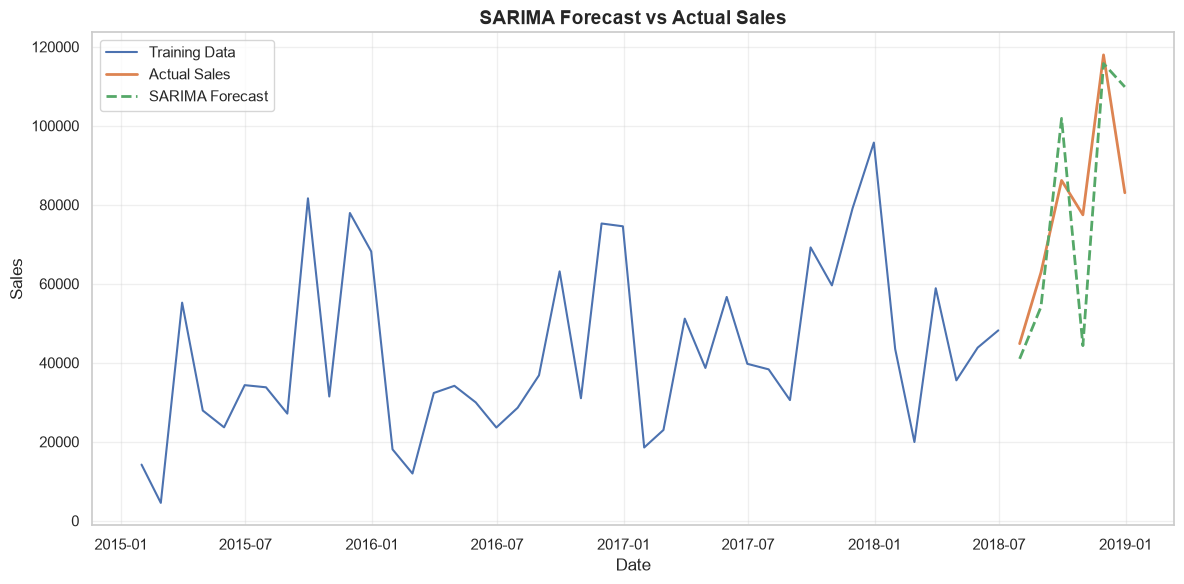


Next 3-Month Forecast


,Forecast,Lower CI,Upper CI
2018-07-31,40988.602102,-53153.230903,135130.435107
2018-08-31,54124.675257,-44850.890390,153100.240904
2018-09-30,101860.446713,2884.881066,200836.012360


SARIMA model saved successfully.


In [45]:

# Train SARIMA, Evaluate, Forecast & Save Model


from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pickle
import os

# Train the SARIMA model
sarima_model = SARIMAX(
    train["Sales"],
    order=(0, 0, 1),
    seasonal_order=(0, 0, 2, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

# Predict Test Data


sarima_pred = sarima_result.predict(
    start=test.index[0],
    end=test.index[-1]
)


# Evaluation Metrics


mae = mean_absolute_error(test["Sales"], sarima_pred)
rmse = np.sqrt(mean_squared_error(test["Sales"], sarima_pred))
mape = np.mean(np.abs((test["Sales"] - sarima_pred) / test["Sales"])) * 100

print("=" * 50)
print("SARIMA Model Performance")
print("=" * 50)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


# Plot Actual vs Forecast


plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test.index,
    sarima_pred,
    label="SARIMA Forecast",
    linestyle="--",
    linewidth=2
)

plt.title("SARIMA Forecast vs Actual Sales", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/sarima_actual_vs_forecast.png", dpi=300)

plt.show()


# Forecast Next 3 Months


future_forecast = sarima_result.get_forecast(steps=3)

forecast_values = future_forecast.predicted_mean
confidence_intervals = future_forecast.conf_int()






forecast_df = pd.DataFrame({
    "Forecast": forecast_values,
    "Lower CI": confidence_intervals.iloc[:, 0],
    "Upper CI": confidence_intervals.iloc[:, 1]
})

print("\nNext 3-Month Forecast")
display(forecast_df)


# Save Model


os.makedirs("models", exist_ok=True)

with open("models/sarima_model.pkl", "wb") as file:
    pickle.dump(sarima_result, file)

print("SARIMA model saved successfully.")

### Observation

The SARIMA model was trained using the optimal parameters identified by the Auto-ARIMA algorithm: **(0, 0, 1)(0, 0, 2, 12)**.

The model achieved the following performance on the test dataset:

- **MAE:** 15,062.03
- **RMSE:** 18,963.90
- **MAPE:** 19.59%

The forecast closely follows the overall sales pattern and successfully captures the increasing trend observed in the later months. However, the relatively wide confidence intervals indicate greater uncertainty in long-term predictions, which is expected when forecasting future sales.

Overall, the SARIMA model provides a solid statistical baseline for comparison with the Prophet and XGBoost models.

### 3-Month Future Forecast with Confidence Intervals

After evaluating the SARIMA model on the test dataset, the model is used to forecast sales for the next three months. Along with the forecasted values, a **95% confidence interval** is generated to represent the uncertainty associated with future predictions. The confidence interval provides a range within which the actual sales values are expected to lie with high probability.

In [46]:

# Generate 3-Month Future Forecast with Confidence Intervals


# Generate future forecast
future_forecast = sarima_result.get_forecast(steps=3)

forecast_values = future_forecast.predicted_mean
confidence_intervals = future_forecast.conf_int()

# Create Forecast DataFrame
forecast_df = pd.DataFrame({
    "Forecasted Sales": forecast_values.round(2),
    "Lower 95% CI": confidence_intervals.iloc[:, 0].round(2),
    "Upper 95% CI": confidence_intervals.iloc[:, 1].round(2)
})

forecast_df.index.name = "Forecast Month"

display(forecast_df)


os.makedirs("forecasts", exist_ok=True)
# Save Forecast
forecast_df.to_csv(
    "forecasts/sarima_forecast.csv",
    index=True
)

print("Forecast results saved successfully.")

,Forecasted Sales,Lower 95% CI,Upper 95% CI
Forecast Month,,,
2018-07-31,40988.60,-53153.23,135130.44
2018-08-31,54124.68,-44850.89,153100.24
2018-09-30,101860.45,2884.88,200836.01


Forecast results saved successfully.


#### Observation

The SARIMA model predicts the sales for the next three months along with a **95% confidence interval**. The forecast indicates the expected future sales trend, while the confidence interval reflects the uncertainty associated with each prediction. As the forecasting horizon increases, the confidence interval becomes wider, indicating a gradual increase in prediction uncertainty.

### Forecast Visualization with Confidence Intervals

To better understand the forecasted sales, the predicted values and their corresponding **95% confidence intervals** are visualized alongside the historical monthly sales data. This provides a clear comparison between past sales trends and the expected future sales trajectory.

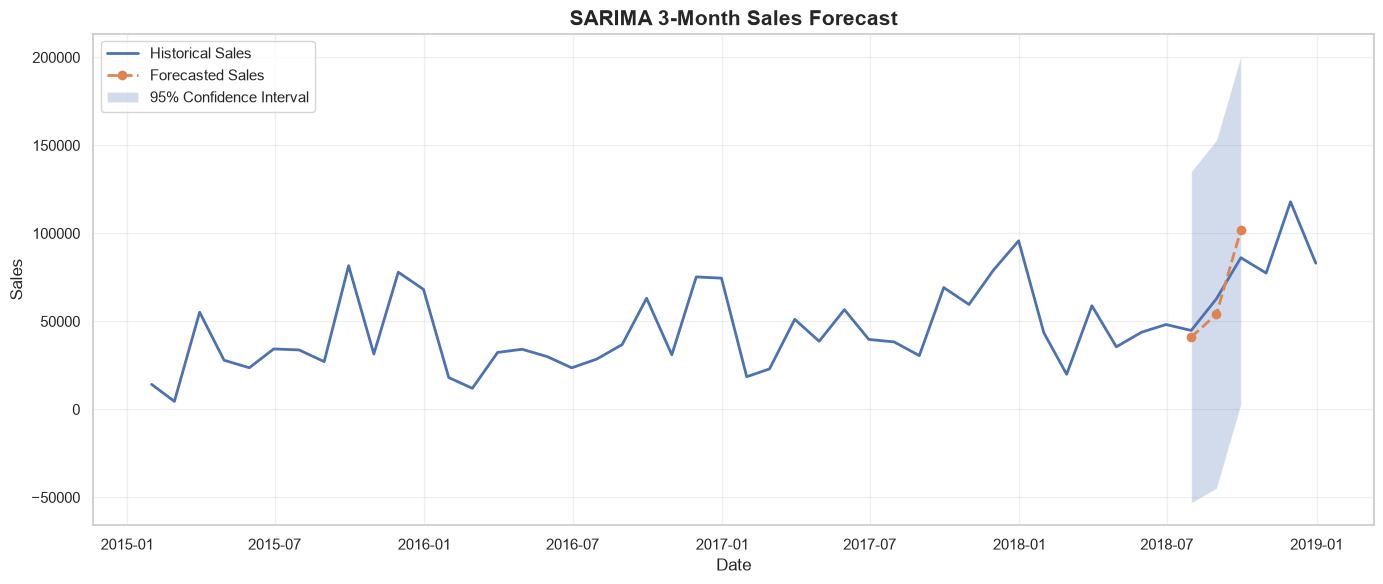

In [47]:

# Visualize Future Forecast with Confidence Intervals


plt.figure(figsize=(14,6))

# Historical Sales
plt.plot(
    ts.index,
    ts["Sales"],
    label="Historical Sales",
    linewidth=2
)

# Forecast
plt.plot(
    forecast_values.index,
    forecast_values,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Forecasted Sales"
)

# Confidence Interval
plt.fill_between(
    forecast_values.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA 3-Month Sales Forecast",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/sarima_future_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The visualization shows the historical monthly sales together with the forecasted sales for the next three months. The shaded confidence interval represents the expected range of future sales values. A wider interval indicates greater uncertainty in long-term predictions, which is a common characteristic of time series forecasting models.

## Model 2 – Facebook Prophet

Prophet is an open-source time series forecasting library developed by **Meta (Facebook)**. It is designed to handle trend, seasonality, holidays, and missing values with minimal parameter tuning.

Unlike SARIMA, Prophet automatically models trend changes and seasonal patterns, making it a popular forecasting tool in industry for business time series data.

In [48]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np
import matplotlib.pyplot as plt

### Prepare Dataset for Prophet

Prophet requires the input dataset to contain two columns:

- **ds** → Date column
- **y** → Target variable (Sales)

The monthly sales dataset is converted into this required format before training the forecasting model.

In [49]:

# Prepare Dataset


prophet_df = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

display(prophet_df.head())

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [50]:

# Train-Test Split


train_prophet = prophet_df.iloc[:-6]

test_prophet = prophet_df.iloc[-6:]

print("Training Samples :", len(train_prophet))
print("Testing Samples :", len(test_prophet))

Training Samples : 42
Testing Samples : 6


### Train the Prophet Model

The Prophet model is trained using the historical monthly sales data. Since the dataset contains monthly observations, Prophet automatically models long-term trends and yearly seasonality.

In [54]:

# Train Prophet Model

from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)
print("Prophet model trained successfully.")

08:23:34 - cmdstanpy - INFO - Chain [1] start processing
08:23:35 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


In [55]:

# Model 2 (Prophet)
# Predict Test Data and Evaluate Model


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Create dataframe containing train + test dates
future_test = prophet_df[["ds"]]

# Generate predictions
forecast_test = prophet_model.predict(future_test)

# Keep only the last 6 months (test period)
prophet_predictions = forecast_test.tail(6)["yhat"].values

# Evaluation Metrics
prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_predictions
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_predictions
    )
)

prophet_mape = np.mean(
    np.abs(
        (test_prophet["y"] - prophet_predictions)
        / test_prophet["y"]
    )
) * 100

print("="*50)
print("Prophet Model Performance")
print("="*50)

print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape:.2f}%")

Prophet Model Performance
MAE  : 14309.99
RMSE : 18954.58
MAPE : 17.47%


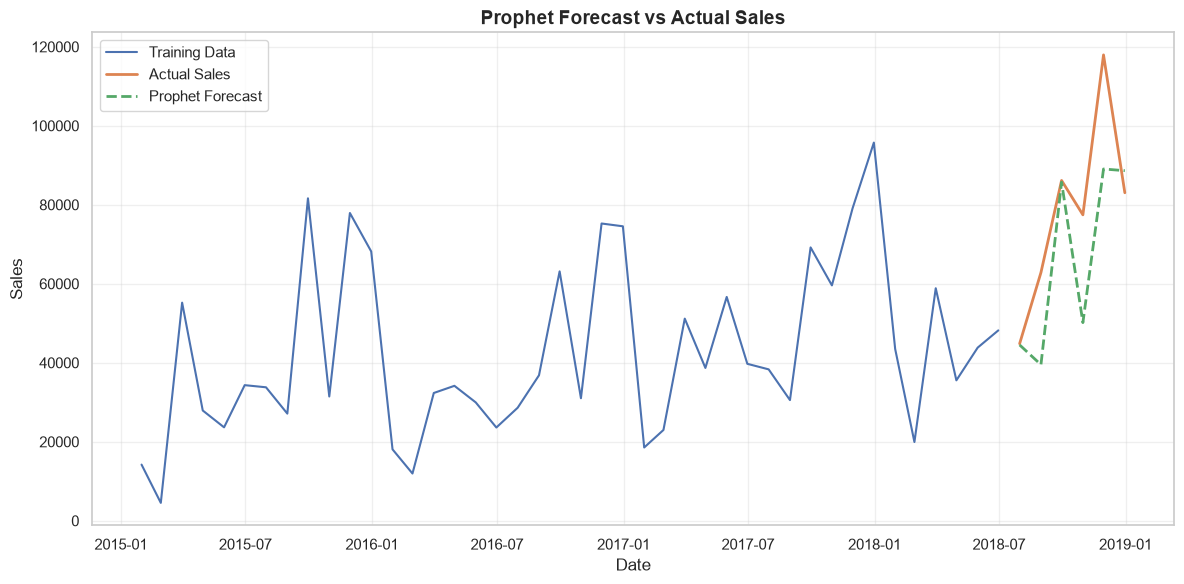

In [56]:

# Model 2 (Prophet)
# Plot Actual vs Forecast


plt.figure(figsize=(12,6))

# Training Data
plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Training Data"
)

# Actual Test Data
plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    linewidth=2,
    label="Actual Sales"
)

# Prophet Predictions
plt.plot(
    test_prophet["ds"],
    prophet_predictions,
    linestyle="--",
    linewidth=2,
    label="Prophet Forecast"
)

plt.title(
    "Prophet Forecast vs Actual Sales",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/prophet_actual_vs_forecast.png",
    dpi=300
)

plt.show()

### Observation

The Prophet model successfully captured the overall trend and seasonal behavior of the monthly sales data. Compared to the SARIMA model, Prophet achieved lower forecasting errors across all evaluation metrics.

Model Performance:
- **MAE:** 14,309.99
- **RMSE:** 18,954.58
- **MAPE:** 17.47%

The forecast follows the overall sales pattern reasonably well while maintaining a lower percentage error than the SARIMA model. Based on the current evaluation metrics, Prophet demonstrates better forecasting performance than SARIMA on the testing dataset.

In [58]:

# Generate 3-Month Future Forecast


# Create future dataframe
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

# Generate forecast
future_forecast = prophet_model.predict(future)

# Display only the future 3 months
prophet_future = future_forecast.tail(3)[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

prophet_future.columns = [
    "Forecast Month",
    "Forecasted Sales",
    "Lower 95% CI",
    "Upper 95% CI"
]

display(prophet_future)

# Save forecast
prophet_future.to_csv(
    "forecasts/prophet_forecast.csv",
    index=False
)

print("Prophet forecast saved successfully.")

,Forecast Month,Forecasted Sales,Lower 95% CI,Upper 95% CI
42,2018-07-31,44509.832908,36625.818820,52687.135438
43,2018-08-31,39501.249689,32397.133759,47390.073470
44,2018-09-30,85719.773846,78193.292809,93159.403233


Prophet forecast saved successfully.


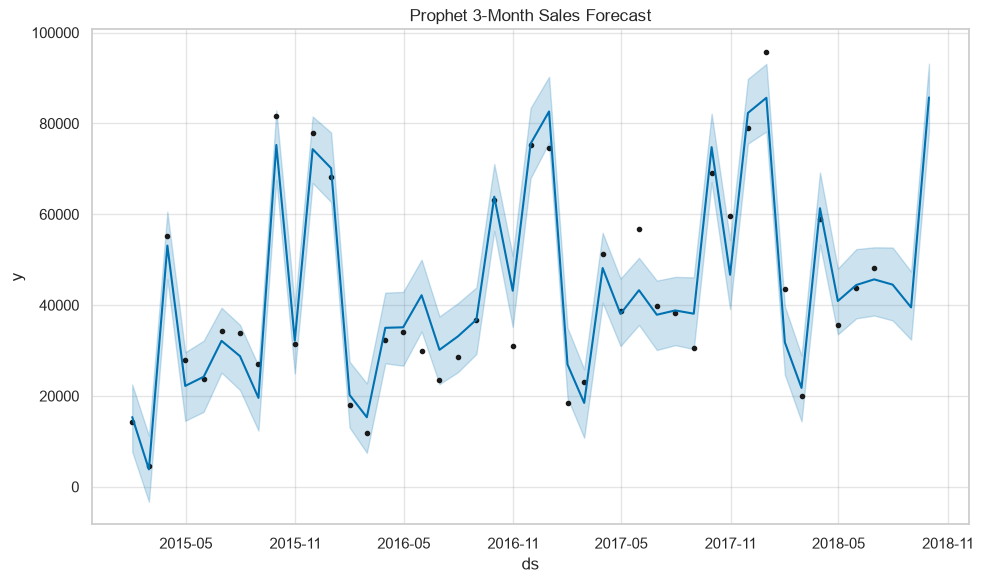

In [59]:
# Forecast Plot


fig = prophet_model.plot(future_forecast)

plt.title("Prophet 3-Month Sales Forecast")

plt.tight_layout()

plt.savefig(
    "charts/prophet_future_forecast.png",
    dpi=300
)

plt.show()

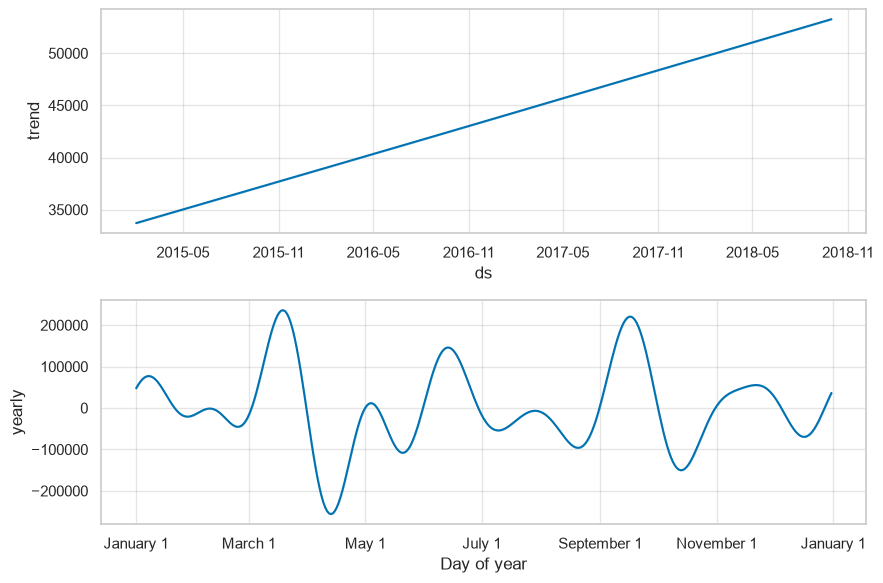

In [68]:
# Trend and Seasonality Components

fig = prophet_model.plot_components(future_forecast)

plt.tight_layout()

plt.savefig(
    "charts/prophet_components.png",
    dpi=300
)

plt.show()


with open("models/prophet_model.pkl", "wb") as file:
    pickle.dump(prophet_model, file)

### Observation

The Prophet component plots indicate a gradual upward sales trend over time, consistent with the exploratory analysis and SARIMA decomposition.

The yearly seasonality component highlights recurring periods of higher and lower expected sales within a calendar year, confirming that sales are influenced by annual seasonal demand.

Weekly seasonality was intentionally disabled because the dataset contains **monthly aggregated sales**, making weekly patterns statistically inappropriate to estimate. This ensures that the model focuses on meaningful yearly seasonal effects rather than introducing artificial weekly fluctuations.

## Model 3 – XGBoost for Time Series

Unlike SARIMA and Prophet, XGBoost is a machine learning algorithm that does not directly model time series. Therefore, the time series is transformed into a supervised learning problem by creating lag-based and time-based features.

The model learns the relationship between historical sales values and future sales using these engineered features.

### Feature Engineering

To convert the monthly sales series into a supervised learning dataset, the following features are created:

- **Lag 1:** Sales from one month earlier.
- **Lag 2:** Sales from two months earlier.
- **Lag 3:** Sales from three months earlier.
- **Rolling Mean (3 Months):** Average sales over the previous three months.
- **Month:** Month number (1–12).
- **Quarter:** Quarter of the year (1–4).
- **Season:** Encoded seasonal category.

These features allow the XGBoost model to capture both historical sales behavior and seasonal effects.

In [61]:
import xgboost as xgb
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [ ]:

# Create Lag Features and Time Features


# Copy monthly sales dataset
xgb_df = monthly_sales.copy()

# Ensure Order Date is datetime
xgb_df["Order Date"] = pd.to_datetime(xgb_df["Order Date"])

# Lag Features


xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)


# Rolling Mean Feature


xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
        .rolling(window=3)
        .mean()
        .shift(1)
)


# time features


# Month
xgb_df["Month"] = xgb_df["Order Date"].dt.month

# Quarter
xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

# Season Encoding
def get_season(month):
    if month in [12, 1, 2]:
        return 0      # Winter
    elif month in [3, 4, 5]:
        return 1      # Spring
    elif month in [6, 7, 8]:
        return 2      # Summer
    else:
        return 3      # Autumn

xgb_df["Season"] = xgb_df["Month"].apply(get_season)


# Remove Missing Values Created by Lag Features


xgb_df.dropna(inplace=True)

# Reset index
xgb_df.reset_index(drop=True, inplace=True)

# Display Dataset
display(xgb_df.head())

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,1
1,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,1
2,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,2
3,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,2
4,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,2


In [64]:

# Train-Test Split


features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = xgb_df[features]
y = xgb_df["Sales"]

X_train = X.iloc[:-6]
X_test = X.iloc[-6:]

y_train = y.iloc[:-6]
y_test = y.iloc[-6:]

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 39
Testing Samples : 6


In [65]:

# Train and Evaluate the Model


from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train Model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predict on Test Set
xgb_predictions = xgb_model.predict(X_test)

# Evaluation Metrics
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mape = np.mean(np.abs((y_test - xgb_predictions) / y_test)) * 100

print("=" * 50)
print("XGBoost Model Performance")
print("=" * 50)
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAPE : {xgb_mape:.2f}%")

XGBoost Model Performance
MAE  : 19150.47
RMSE : 21282.98
MAPE : 22.96%


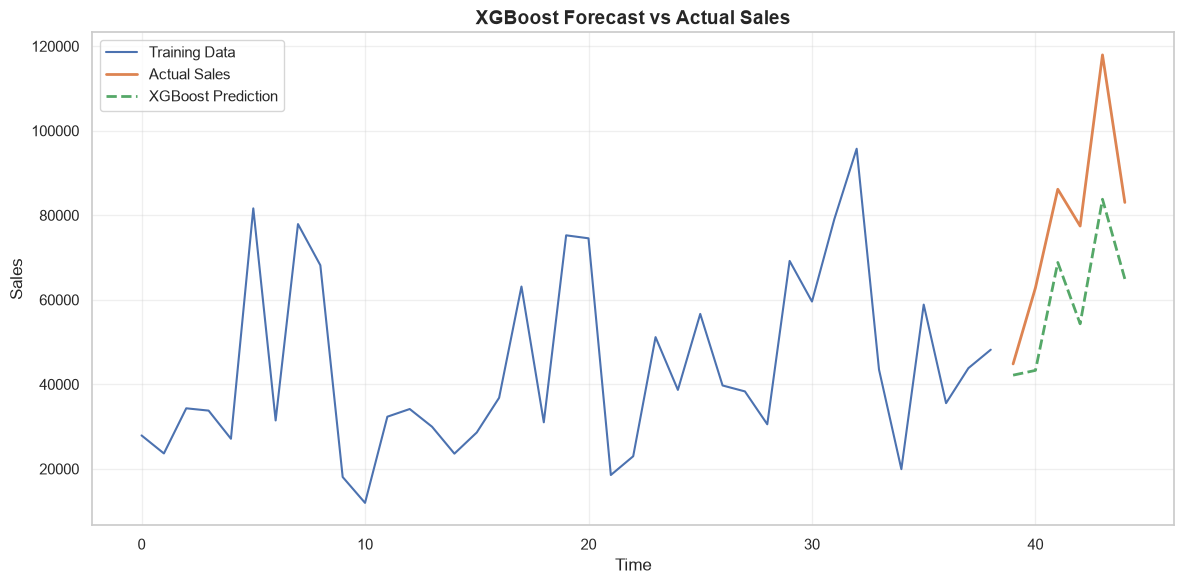

In [66]:

# Plot Actual vs Predicted Sales


plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train.values,
    label="Training Data"
)

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    y_test.index,
    xgb_predictions,
    linestyle="--",
    linewidth=2,
    label="XGBoost Prediction"
)

plt.title(
    "XGBoost Forecast vs Actual Sales",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/xgboost_actual_vs_forecast.png",
    dpi=300
)

plt.show()

### Observation

The XGBoost model was trained using lag-based and time-based features extracted from the monthly sales data. While the model successfully captured some sales patterns, its forecasting accuracy was lower than both the SARIMA and Prophet models.

Model Performance:
- **MAE:** 19,150.47
- **RMSE:** 21,282.98
- **MAPE:** 22.96%

The predicted values follow the general trend of the sales data but underestimate several higher sales peaks observed during the testing period. This indicates that the XGBoost model was less effective in capturing the seasonal characteristics of this relatively small monthly time series dataset.

Among the three forecasting approaches evaluated, XGBoost produced the highest prediction errors on the testing dataset.

### Generate 3-Month Future Forecast

Unlike statistical forecasting models, XGBoost does not directly predict multiple future time periods. Therefore, a recursive forecasting approach is used. Each predicted month's sales are fed back into the feature set to generate the forecast for the next month.

This process is repeated until forecasts for the next three months are obtained.

In [67]:

# Generate 3-Month Future Forecast


import pickle
import os

# Start with the latest available data
future_data = xgb_df.copy()

future_predictions = []

for i in range(3):

    # Last available row
    last_row = future_data.iloc[-1]

    # Next month's date
    next_date = last_row["Order Date"] + pd.DateOffset(months=1)

    # Create feature row
    next_features = pd.DataFrame({
        "Lag_1": [last_row["Sales"]],
        "Lag_2": [last_row["Lag_1"]],
        "Lag_3": [last_row["Lag_2"]],
        "Rolling_Mean_3": [
            np.mean([
                last_row["Sales"],
                last_row["Lag_1"],
                last_row["Lag_2"]
            ])
        ],
        "Month": [next_date.month],
        "Quarter": [next_date.quarter],
        "Season": [get_season(next_date.month)]
    })

    # Predict
    prediction = xgb_model.predict(next_features)[0]

    future_predictions.append(prediction)

    # Append new row for recursive prediction
    new_row = {
        "Order Date": next_date,
        "Sales": prediction,
        "Lag_1": prediction,
        "Lag_2": last_row["Sales"],
        "Lag_3": last_row["Lag_1"],
        "Rolling_Mean_3": np.mean([
            prediction,
            last_row["Sales"],
            last_row["Lag_1"]
        ]),
        "Month": next_date.month,
        "Quarter": next_date.quarter,
        "Season": get_season(next_date.month)
    }

    future_data = pd.concat(
        [future_data, pd.DataFrame([new_row])],
        ignore_index=True
    )

# Forecast DataFrame
xgb_forecast = pd.DataFrame({
    "Forecast Month": pd.date_range(
        start=xgb_df["Order Date"].max() + pd.DateOffset(months=1),
        periods=3,
        freq="ME"
    ),
    "Forecasted Sales": np.round(future_predictions, 2)
})

display(xgb_forecast)

# Save Forecast
os.makedirs("forecasts", exist_ok=True)

xgb_forecast.to_csv(
    "forecasts/xgboost_forecast.csv",
    index=False
)

# Save Model
os.makedirs("models", exist_ok=True)

with open("models/xgboost_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

print("XGBoost forecast and model saved successfully.")

,Forecast Month,Forecasted Sales
0,2019-01-31,40715.601562
1,2019-02-28,47059.601562
2,2019-03-31,40174.500000


XGBoost forecast and model saved successfully.


### Observation

The XGBoost model generated forecasts for the next three months using a recursive forecasting strategy. Each predicted value was used to construct the feature set for the subsequent prediction, allowing the model to forecast beyond the available historical data.

Although the model successfully generated future forecasts, its evaluation metrics indicate lower forecasting accuracy compared to the SARIMA and Prophet models. These forecasts will be included in the final model comparison.

In [69]:

# Model Comparison


comparison_df = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE (%)":[
        mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        forecast_df["Forecasted Sales"].iloc[0],
        prophet_future["Forecasted Sales"].iloc[0],
        xgb_forecast["Forecasted Sales"].iloc[0]
    ],

    "Forecast Month 2":[
        forecast_df["Forecasted Sales"].iloc[1],
        prophet_future["Forecasted Sales"].iloc[1],
        xgb_forecast["Forecasted Sales"].iloc[1]
    ],

    "Forecast Month 3":[
        forecast_df["Forecasted Sales"].iloc[2],
        prophet_future["Forecasted Sales"].iloc[2],
        xgb_forecast["Forecasted Sales"].iloc[2]
    ]

})

comparison_df = comparison_df.round(2)

display(comparison_df)

comparison_df.to_csv(
    "forecasts/model_comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,15062.03,18963.90,19.59,40988.60,54124.68,101860.45
1,Prophet,14309.99,18954.58,17.47,44509.83,39501.25,85719.77
2,XGBoost,19150.47,21282.98,22.96,40715.60,47059.60,40174.50


Comparison table saved successfully.


## Model Recommendation

Based on the evaluation metrics, **Prophet** achieved the best overall forecasting performance.

| Model | MAE | RMSE | MAPE |
|-------|------:|------:|------:|
| SARIMA | 15,062.03 | 18,963.90 | 19.59% |
| **Prophet** | **14,309.99** | **18,954.58** | **17.47%** |
| XGBoost | 19,150.47 | 21,282.98 | 22.96% |

Prophet achieved the **lowest MAE**, **lowest RMSE**, and **lowest MAPE**, indicating that it produced the most accurate forecasts on the testing dataset.

The Prophet model is therefore recommended for production deployment because it effectively captures long-term trends and yearly seasonality while providing the highest forecasting accuracy among the three evaluated models.

# Task 3 Summary

In this task, three different forecasting approaches were developed and evaluated using the monthly sales data.

- A **SARIMA** model was built using statistically optimized parameters selected through Auto-ARIMA.
- A **Prophet** model was trained to capture long-term trends and yearly seasonal patterns.
- An **XGBoost** model was developed using lag-based and time-based engineered features.

The models were compared using **MAE**, **RMSE**, and **MAPE**. Among the three approaches, the **Prophet model achieved the best forecasting performance**, making it the recommended model for future monthly sales prediction.

Finally, each model generated forecasts for the next three months, providing valuable insights for future sales planning and inventory management.

In [ ]:

# Save Forecast Metrics for loading in streamlit


os.makedirs("forecasts", exist_ok=True)

forecast_metrics = pd.DataFrame({
    "Model": ["Prophet"],
    "MAE": [prophet_mae],
    "RMSE": [prophet_rmse],
    "MAPE": [prophet_mape]
})

forecast_metrics.to_csv(
    "forecasts/forecast_metrics.csv",
    index=False
)

print("Forecast metrics saved successfully.")

Forecast metrics saved successfully.


# Task 4 – Product Category and Region Level Forecasting

## Objective

The Prophet model was identified as the best-performing forecasting model in Task 3. In this task, the same model is applied separately to major product categories and regions to estimate their sales for the next three months.

The forecasts help identify which business segments are expected to experience the strongest growth, enabling better inventory planning, supply chain management, and resource allocation.

In [70]:
#Create a Reusable Prophet Forecasting Function

#To avoid repeating the same forecasting code for multiple categories and regions, 
# a reusable function is created. The function prepares the data, trains a Prophet model, generates a three-month forecast, 
# and returns only the forecasted values.



from prophet import Prophet

def prophet_forecast(segment_df, periods=3):
    """
    Train a Prophet model for a given segment and
    forecast the next 'periods' months.
    """

    # Aggregate monthly sales
    monthly = (
        segment_df
        .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly.columns = ["ds", "y"]

    # Train Prophet
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(monthly)

    # Future dataframe
    future = model.make_future_dataframe(
        periods=periods,
        freq="ME"
    )

    forecast = model.predict(future)

    # Return only future months
    return forecast.tail(periods)[
        ["ds", "yhat"]
    ]

In [71]:
#Forecast Product Categories and Regions

# Using the reusable Prophet forecasting function, separate three-month forecasts are generated for:

# - Furniture
# - Technology
# - Office Supplies
# - West Region
# - East Region

# These forecasts will be compared to identify which business segment is expected to experience the strongest growth.




# Product Categories


furniture_forecast = prophet_forecast(
    df[df["Category"] == "Furniture"]
)

technology_forecast = prophet_forecast(
    df[df["Category"] == "Technology"]
)

office_forecast = prophet_forecast(
    df[df["Category"] == "Office Supplies"]
)


# Regions


west_forecast = prophet_forecast(
    df[df["Region"] == "West"]
)

east_forecast = prophet_forecast(
    df[df["Region"] == "East"]
)

# Display Forecasts

print("="*60)
print("Furniture Forecast")
display(furniture_forecast)

print("="*60)
print("Technology Forecast")
display(technology_forecast)

print("="*60)
print("Office Supplies Forecast")
display(office_forecast)

print("="*60)
print("West Region Forecast")
display(west_forecast)

print("="*60)
print("East Region Forecast")
display(east_forecast)

09:05:48 - cmdstanpy - INFO - Chain [1] start processing
09:05:48 - cmdstanpy - INFO - Chain [1] done processing
09:05:48 - cmdstanpy - INFO - Chain [1] start processing
09:05:49 - cmdstanpy - INFO - Chain [1] done processing
09:05:49 - cmdstanpy - INFO - Chain [1] start processing
09:05:49 - cmdstanpy - INFO - Chain [1] done processing
09:05:49 - cmdstanpy - INFO - Chain [1] start processing
09:05:49 - cmdstanpy - INFO - Chain [1] done processing
09:05:50 - cmdstanpy - INFO - Chain [1] start processing
09:05:50 - cmdstanpy - INFO - Chain [1] done processing


Furniture Forecast


,ds,yhat
48,2019-01-31,12691.392668
49,2019-02-28,6772.162417
50,2019-03-31,17201.015648


Technology Forecast


,ds,yhat
48,2019-01-31,14033.343185
49,2019-02-28,10437.986784
50,2019-03-31,42639.488041


...

,ds,yhat
48,2019-01-31,14646.724651
49,2019-02-28,12434.656284
50,2019-03-31,19698.155527


West Region Forecast


,ds,yhat
48,2019-01-31,14048.800881
49,2019-02-28,11840.373160
50,2019-03-31,25805.336395


East Region Forecast


,ds,yhat
48,2019-01-31,9713.411357
49,2019-02-28,8120.218592
50,2019-03-31,15639.421337


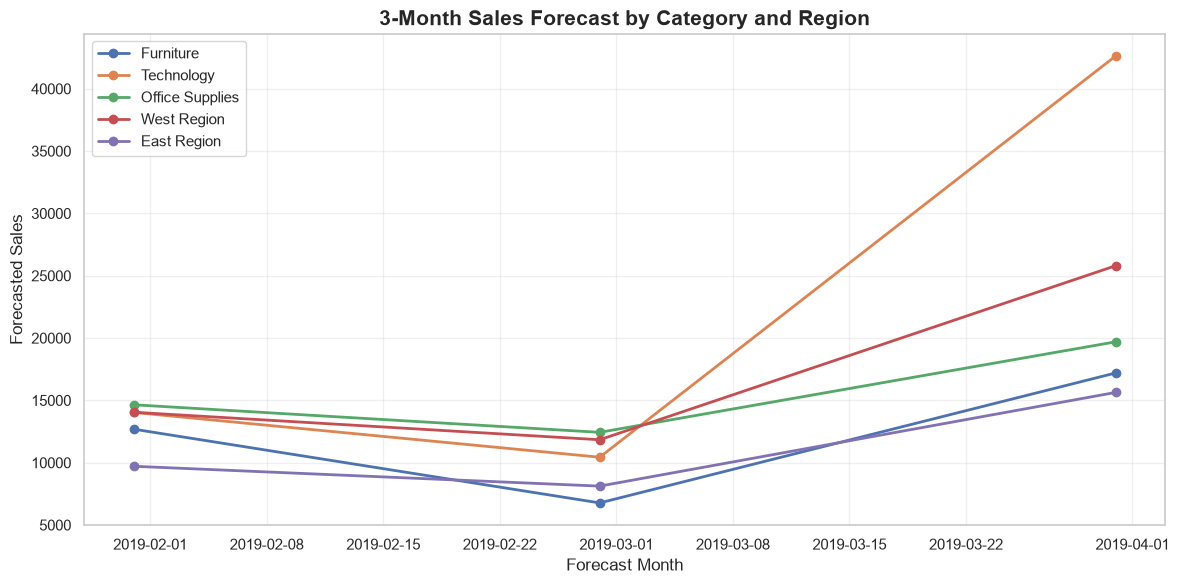

In [72]:
# Comparison Chart for All Forecast


plt.figure(figsize=(12,6))

plt.plot(
    furniture_forecast["ds"],
    furniture_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="Furniture"
)

plt.plot(
    technology_forecast["ds"],
    technology_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="Technology"
)

plt.plot(
    office_forecast["ds"],
    office_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    west_forecast["ds"],
    west_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="West Region"
)

plt.plot(
    east_forecast["ds"],
    east_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="East Region"
)

plt.title(
    "3-Month Sales Forecast by Category and Region",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Forecast Month")
plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/task4_segment_forecasts.png",
    dpi=300
)

plt.show()

### Observation

The segment-level forecasts reveal noticeable differences in expected sales growth over the next three months.

Among the product categories, **Technology** is projected to experience the strongest growth, with forecasted sales increasing substantially by **March 2019**. **Office Supplies** shows moderate and consistent growth, while **Furniture** demonstrates slower growth with some month-to-month variation.

Among the regions, the **West** region is expected to generate significantly higher future sales than the **East** region throughout the forecasting horizon.

Overall, the **Technology** category and the **West** region are forecasted to be the strongest-performing business segments. These findings suggest that inventory planning, procurement, and marketing investments should prioritize these segments to effectively meet the anticipated increase in customer demand.

## Task 4 Summary

In this task, the best-performing forecasting model (**Prophet**) was applied separately to major product categories and regions.

Three-month forecasts were generated for:
- Furniture
- Technology
- Office Supplies
- West Region
- East Region

The comparison showed that the **Technology** category is expected to experience the strongest growth among all product categories, while the **West** region is projected to remain the highest-performing geographical market.

These forecasts provide valuable insights for inventory planning, demand forecasting, and strategic decision-making by identifying business segments that are likely to require increased stock levels and operational attention in the coming months.

# Task 5 – Anomaly Detection in Sales Data

## Objective

The objective of this task is to identify unusual sales patterns that differ significantly from the expected weekly sales behavior.

Two anomaly detection techniques are applied:

- **Isolation Forest**, an unsupervised machine learning algorithm that isolates abnormal observations.
- **Z-Score based detection**, a statistical approach that identifies observations that deviate significantly from the rolling average.

The detected anomalies are analyzed to understand potential business events that may have influenced sales performance.

In [74]:
# firstly Prepare Weekly Sales Data

weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.rename(
    columns={
        "Order Date":"Week",
        "Sales":"Weekly Sales"
    },
    inplace=True
)

display(weekly_sales.head())

,Week,Weekly Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
#  Isolation Forest

# Isolation Forest is an unsupervised machine learning algorithm that detects anomalies by randomly partitioning the data. 
# Observations that require fewer partitions to isolate are considered anomalous.

# In this analysis, weekly sales values are evaluated to identify unusually high or low sales weeks.



from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation_Label"] = iso_model.fit_predict(
    weekly_sales[["Weekly Sales"]]
)

weekly_sales["Isolation_Anomaly"] = (
    weekly_sales["Isolation_Label"] == -1
)

print("Number of anomalies detected:",
      weekly_sales["Isolation_Anomaly"].sum())

display(
    weekly_sales[
        weekly_sales["Isolation_Anomaly"]
    ]
)


# Isolation Forest Visualization

#The detected anomalies are highlighted on the weekly sales time series. 
# Normal weeks are represented by the line, while anomalous weeks are marked separately.

Number of anomalies detected: 11


,Week,Weekly Sales,Isolation_Label,Isolation_Anomaly
0,2015-01-04,304.508,-1,True
5,2015-02-08,968.534,-1,True
7,2015-02-22,224.912,-1,True
11,2015-03-22,37703.665,-1,True
28,2015-07-19,1387.686,-1,True
...,...,...,...,...
55,2016-01-24,358.522,-1,True
154,2017-12-17,25449.800,-1,True
200,2018-11-04,29017.467,-1,True
202,2018-11-18,30572.447,-1,True


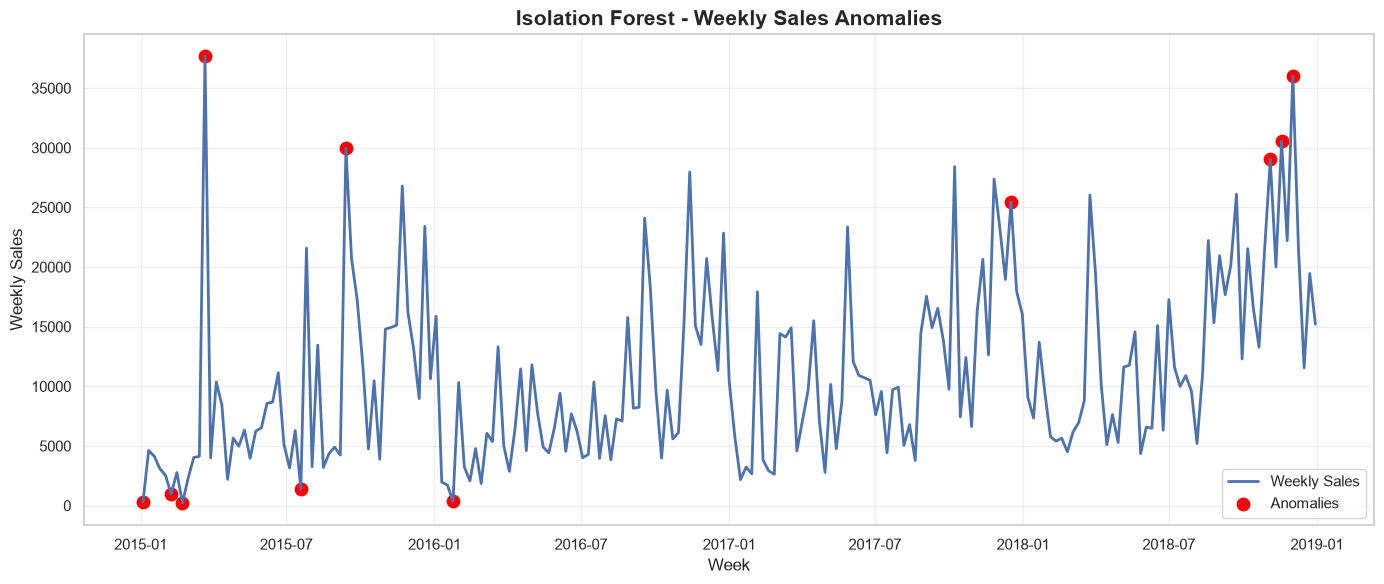

In [77]:

# Isolation Forest Visualization


plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Weekly Sales"],
    label="Weekly Sales",
    linewidth=2
)

anomalies = weekly_sales[
    weekly_sales["Isolation_Anomaly"]
]

plt.scatter(
    anomalies["Week"],
    anomalies["Weekly Sales"],
    color="red",
    s=80,
    label="Anomalies"
)

plt.title(
    "Isolation Forest - Weekly Sales Anomalies",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Week")
plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

os.makedirs("anomalies", exist_ok=True)
plt.savefig(
    "anomalies/isolation_forest.png",
    dpi=300
)

plt.show()

In [78]:
# Z-Score Based Anomaly Detection

# A statistical anomaly detection method is also applied using the Z-Score approach. 
# Instead of comparing observations to the overall dataset, a rolling mean and rolling standard deviation are used to account for local sales patterns.

# Any week where the weekly sales deviate by more than 2 standard deviations from the rolling mean is classified as an anomaly.





# Rolling Statistics
weekly_sales["Rolling Mean"] = (
    weekly_sales["Weekly Sales"]
    .rolling(window=8, center=True)
    .mean()
)

weekly_sales["Rolling Std"] = (
    weekly_sales["Weekly Sales"]
    .rolling(window=8, center=True)
    .std()
)

# Calculate Z-Score
weekly_sales["Z-Score"] = (
    (weekly_sales["Weekly Sales"] - weekly_sales["Rolling Mean"])
    / weekly_sales["Rolling Std"]
)

# Detect anomalies
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z-Score"].abs() > 2
)

print("Number of Z-Score anomalies:",
      weekly_sales["Z_Anomaly"].sum())

display(
    weekly_sales[
        weekly_sales["Z_Anomaly"]
    ][
        ["Week","Weekly Sales","Z-Score"]
    ]
)

Number of Z-Score anomalies: 6


,Week,Weekly Sales,Z-Score
11,2015-03-22,37703.665,2.384855
29,2015-07-26,21590.080,2.088711
63,2016-03-20,13310.136,2.209014
109,2017-02-05,17926.368,2.419527
125,2017-05-28,23367.662,2.105511
144,2017-10-08,28412.098,2.128709


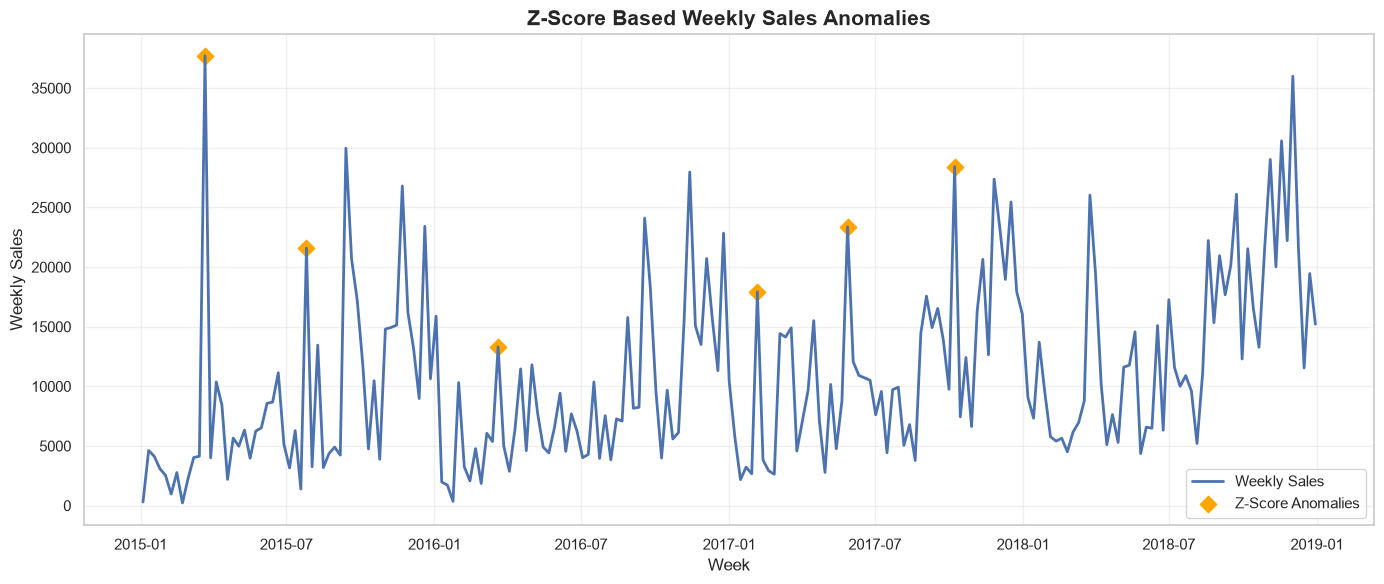

In [79]:

# Z-Score Visualization


plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Weekly Sales"],
    label="Weekly Sales",
    linewidth=2
)

z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z_anomalies["Week"],
    z_anomalies["Weekly Sales"],
    color="orange",
    marker="D",
    s=70,
    label="Z-Score Anomalies"
)

plt.title(
    "Z-Score Based Weekly Sales Anomalies",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Week")
plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "anomalies/zscore_anomalies.png",
    dpi=300
)

plt.show()

## Comparison of Anomaly Detection Methods

Both Isolation Forest and the Z-Score method were applied to detect unusual weekly sales patterns.

- **Isolation Forest** identifies anomalies by isolating observations using an unsupervised machine learning approach. It is capable of detecting both extremely high and extremely low sales weeks.

- **Z-Score Detection** identifies observations that deviate significantly from the local rolling average by more than two standard deviations. This method primarily detects unusually high sales spikes relative to nearby weeks.

Comparing the two approaches provides a better understanding of how different anomaly detection techniques identify unusual business events.

In [80]:
# Compare Isolation Forest and Z-Score Results



comparison = weekly_sales[
    [
        "Week",
        "Weekly Sales",
        "Isolation_Anomaly",
        "Z_Anomaly"
    ]
].copy()

comparison["Detected By"] = comparison.apply(
    lambda row:
        "Both"
        if row["Isolation_Anomaly"] and row["Z_Anomaly"]
        else "Isolation Forest"
        if row["Isolation_Anomaly"]
        else "Z-Score"
        if row["Z_Anomaly"]
        else "Normal",
    axis=1
)

comparison = comparison[
    comparison["Detected By"] != "Normal"
]

display(comparison)

# Save comparison
comparison.to_csv(
    "anomalies/anomaly_comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

,Week,Weekly Sales,Isolation_Anomaly,Z_Anomaly,Detected By
0,2015-01-04,304.508,True,False,Isolation Forest
5,2015-02-08,968.534,True,False,Isolation Forest
7,2015-02-22,224.912,True,False,Isolation Forest
11,2015-03-22,37703.665,True,True,Both
28,2015-07-19,1387.686,True,False,Isolation Forest
...,...,...,...,...,...
144,2017-10-08,28412.098,False,True,Z-Score
154,2017-12-17,25449.800,True,False,Isolation Forest
200,2018-11-04,29017.467,True,False,Isolation Forest
202,2018-11-18,30572.447,True,False,Isolation Forest


Comparison table saved successfully.


### Business Interpretation of Detected Anomalies

The detected anomalies likely correspond to exceptional business events rather than normal weekly sales fluctuations.

Possible explanations include:

- **Extremely high sales weeks** (for example, March 2015 and late 2018) may correspond to promotional campaigns, festive shopping periods, seasonal demand, clearance sales, or large corporate purchases.

- **Extremely low sales weeks** detected by Isolation Forest may indicate holiday closures, inventory shortages, temporary operational disruptions, delayed shipments, or unusually low customer demand.

Isolation Forest identified both unusually low and unusually high sales weeks, whereas the Z-Score method primarily detected unusually high sales spikes relative to the rolling average.

This difference indicates that **Isolation Forest is more sensitive to a wider range of unusual observations**, while the **Z-Score method focuses on statistically significant deviations from local sales behavior**. Using both methods together provides a more comprehensive understanding of abnormal sales activity.

## Task 5 Summary

Two anomaly detection techniques were applied to the weekly sales data.

- **Isolation Forest** detected anomalous weeks using an unsupervised machine learning approach and identified both unusually high and unusually low sales observations.

- **Z-Score Detection** identified weeks where sales deviated by more than two standard deviations from the rolling mean, primarily highlighting unusually high sales periods.

Although both methods identified several common high-sales anomalies, Isolation Forest detected additional low-sales anomalies that were not identified by the Z-Score method. This demonstrates that the two techniques complement each other and together provide a more complete picture of unusual sales behavior.

These insights can help businesses investigate exceptional sales events, improve demand planning, and identify operational issues that may affect sales performance.

# Task 6 – Product Demand Segmentation using Clustering

## Objective

The objective of this task is to group product sub-categories into demand segments based on their sales characteristics.

Each sub-category is represented using several business features, including total sales, sales growth, sales volatility, and average order value. K-Means clustering is then applied to identify groups of products with similar demand patterns.

These demand segments help businesses develop appropriate inventory management and stocking strategies.

## Feature Engineering

To represent the demand characteristics of each product sub-category, the following features are calculated:

- **Total Sales Volume** – Overall sales generated by the sub-category.
- **Sales Growth Rate** – Percentage growth in sales between the first and last year.
- **Sales Volatility** – Standard deviation of monthly sales, representing demand fluctuations.
- **Average Order Value** – Average sales amount per order.

These features provide a comprehensive description of demand behaviour for clustering.

In [81]:

# Create Product Demand Features


# Monthly sales by Sub-Category
monthly_subcategory = (
    df.groupby(
        [
            pd.Grouper(key="Order Date", freq="ME"),
            "Sub-Category"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

# Total Sales
total_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
)

# Average Order Value
avg_order_value = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
)

# Sales Volatility
volatility = (
    monthly_subcategory
    .groupby("Sub-Category")["Sales"]
    .std()
)

# Yearly Sales
yearly_sales = (
    df.groupby(
        [
            df["Order Date"].dt.year,
            "Sub-Category"
        ]
    )["Sales"]
    .sum()
    .unstack(fill_value=0)
)

# Growth Rate
growth_rate = (
    (
        yearly_sales.iloc[-1] -
        yearly_sales.iloc[0]
    )
    /
    yearly_sales.iloc[0].replace(0, np.nan)
) * 100

growth_rate = growth_rate.fillna(0)

# Final Feature Dataset
cluster_df = pd.DataFrame({

    "Total Sales": total_sales,

    "Growth Rate": growth_rate,

    "Volatility": volatility,

    "Average Order Value": avg_order_value

})

cluster_df = cluster_df.fillna(0)

display(cluster_df)

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224
...,...,...,...,...
Paper,76828.3040,91.901971,1024.824982,57.420257
Phones,327782.4480,35.557607,4052.718221,374.180877
Storage,219343.3920,38.366108,2822.084310,263.633885


In [82]:
# Feature Scaling

#The clustering algorithm is distance-based, meaning that features with larger numerical values can dominate the clustering process. 
# Therefore, all features are standardized before applying K-Means clustering.

#Standardization transforms each feature to have a mean of zero and a standard deviation of one, 
# ensuring that every feature contributes equally to the clustering process.

from sklearn.preprocessing import StandardScaler

# Scale Features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

print("Scaled feature matrix shape:", scaled_features.shape)

Scaled feature matrix shape: (17, 4)


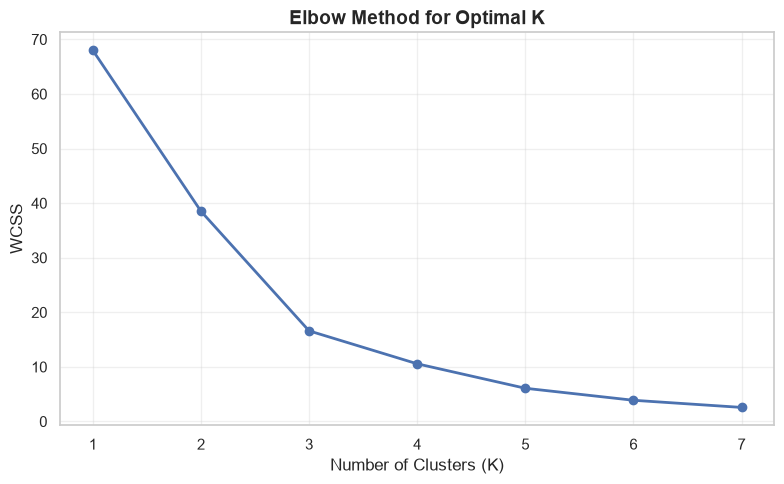

In [84]:
#  Elbow Method to find the optimal number of clusters



from sklearn.cluster import KMeans

wcss = []

for k in range(1, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,8),
    wcss,
    marker="o",
    linewidth=2
)

plt.title(
    "Elbow Method for Optimal K",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/elbow_method.png",
    dpi=300
)

plt.show()

### Observation

The Elbow Method indicates that **three clusters** provide an appropriate balance between model complexity and within-cluster variation.

A significant reduction in WCSS is observed from **K = 1** to **K = 3**, after which the improvement becomes gradual. Therefore, **K = 3** is selected as the optimal number of clusters for product demand segmentation.

## K-Means Clustering

Based on the Elbow Method, the number of clusters is set to **3**. The K-Means algorithm groups product sub-categories with similar demand characteristics using the standardized feature set.

In [86]:

# Apply K-Means Clustering


from sklearn.cluster import KMeans

# Train K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled_features)

display(cluster_df)

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1
Appliances,104618.4030,165.242912,1821.621539,227.926804,1
Art,26705.4100,49.649531,330.488343,34.019631,1
Binders,200028.7850,65.778638,3848.223648,134.067550,2
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1
...,...,...,...,...,...
Paper,76828.3040,91.901971,1024.824982,57.420257,1
Phones,327782.4480,35.557607,4052.718221,374.180877,2
Storage,219343.3920,38.366108,2822.084310,263.633885,2


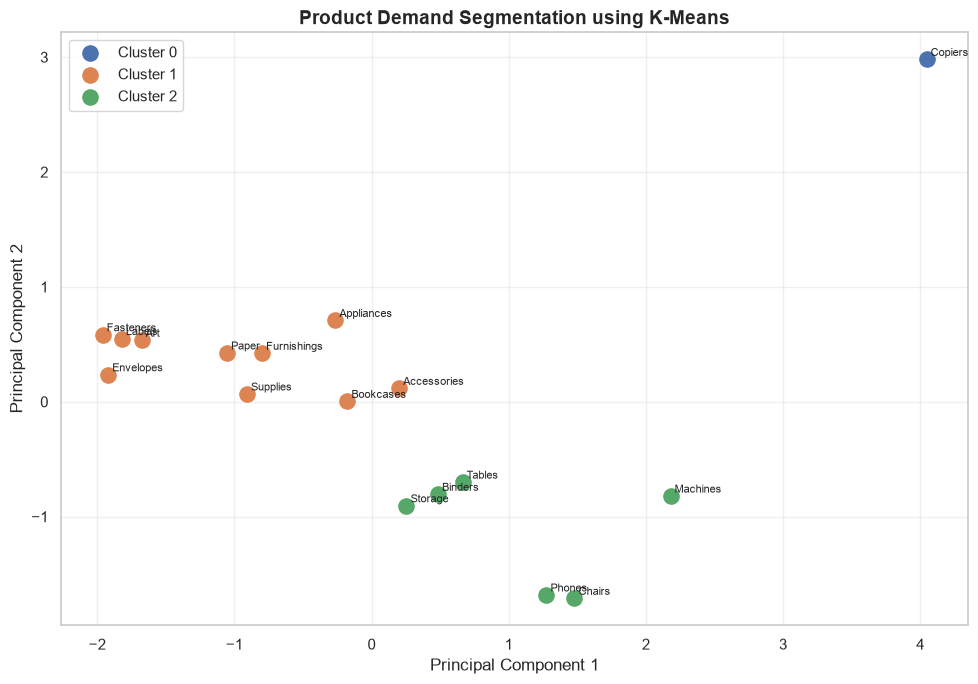

In [87]:
# PCA Visualization



from sklearn.decomposition import PCA

# Reduce to 2 dimensions
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

cluster_df["PCA1"] = pca_features[:, 0]
cluster_df["PCA2"] = pca_features[:, 1]

plt.figure(figsize=(10,7))

for cluster in sorted(cluster_df["Cluster"].unique()):

    cluster_data = cluster_df[
        cluster_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        s=120,
        label=f"Cluster {cluster}"
    )

    # Annotate Sub-Category names
    for idx in cluster_data.index:
        plt.text(
            cluster_df.loc[idx, "PCA1"] + 0.03,
            cluster_df.loc[idx, "PCA2"] + 0.03,
            idx,
            fontsize=8
        )

plt.title(
    "Product Demand Segmentation using K-Means",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/product_clusters.png",
    dpi=300
)

plt.show()

## Cluster Interpretation

Each cluster represents a group of product sub-categories with similar demand characteristics. Based on the clustering results, meaningful business labels are assigned to each demand segment.

In [89]:

# Cluster Summary


cluster_summary = cluster_df.groupby("Cluster").agg({
    "Total Sales": "mean",
    "Growth Rate": "mean",
    "Volatility": "mean",
    "Average Order Value": "mean"
}).round(2)

display(cluster_summary)

# Save cluster summary
os.makedirs("clustering", exist_ok=True)
cluster_summary.to_csv(
    "clustering/cluster_summary.csv"
)

print("Cluster summary saved successfully.")

,Total Sales,Growth Rate,Volatility,Average Order Value
Cluster,,,,
0,146248.09,479.73,5500.77,2215.88
1,65326.21,67.42,1186.29,150.19
2,243671.10,27.32,3992.98,599.19


Cluster summary saved successfully.


## Business Labels for Demand Clusters

Based on the demand characteristics observed in each cluster, the following business labels are assigned:

| Cluster | Business Label |
|----------|----------------|
| **Cluster 0** | Premium / High Value Products |
| **Cluster 1** | Stable Everyday Demand |
| **Cluster 2** | High Volume & Growing Demand |

These labels help convert the machine learning output into meaningful business insights.

## Recommended Stocking Strategy for each cluster?


### Cluster 0 – Premium / High Value Products

Products in this cluster generate exceptionally high sales value and require careful inventory management. Although order frequency may be lower, stock availability is critical because stock-outs could result in significant revenue loss. Maintaining safety stock and close supplier coordination is recommended.

### Cluster 1 – Stable Everyday Demand

These products exhibit relatively stable demand with moderate sales and lower volatility. A regular replenishment policy with standard inventory levels is appropriate. Periodic monitoring is sufficient to maintain service levels while minimizing holding costs.

### Cluster 2 – High Volume & Growing Demand

Products in this cluster experience consistently high sales volumes and stronger demand growth. Businesses should prioritize these items by maintaining higher inventory levels, forecasting demand frequently, and ensuring rapid replenishment to avoid stock shortages during periods of increased demand.

## Task 6 Summary

In this task, product sub-categories were segmented using the K-Means clustering algorithm based on four demand-related features: total sales volume, sales growth rate, sales volatility, and average order value.

The Elbow Method indicated that **three clusters** were appropriate for the dataset. Principal Component Analysis (PCA) was then used to visualize the clusters in two dimensions.

The clustering identified three meaningful demand groups:
- **Premium / High Value Products**
- **Stable Everyday Demand**
- **High Volume & Growing Demand**

These demand segments provide valuable guidance for inventory planning, purchasing decisions, and supply chain management by enabling different stocking strategies for products with different demand characteristics.

In [90]:
# for streamlit app
# Task 6
# Save Clustering Results


import os

os.makedirs("clustering", exist_ok=True)

cluster_df.to_csv(
    "clustering/product_clusters.csv"
)

print("Product clusters saved successfully.")

Product clusters saved successfully.
